# TF -IDF

In [1]:
# =========================
# CONFIGURACIÓN INICIAL
# =========================

import os, time, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

SEED = 42
np.random.seed(SEED)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    classification_report,accuracy_score,confusion_matrix,
    precision_score,recall_score,f1_score
)
from xgboost import XGBClassifier


In [2]:
# Carga y limpieza de datos
# -------------------------
df = pd.read_csv(
    'https://raw.githubusercontent.com/Darally06/NLP-Jarvis-Hiring/refs/heads/main/Data/Clean_words.csv'
)
df = df.rename(columns={'macro_label': 'Category'})
print(f"Registros totales: {len(df)}")

# Usar la columna 'clean_text' para el texto
df['text'] = df['clean_text']

# Codificación de etiquetas
le = LabelEncoder()
df["label"] = le.fit_transform(df["Category"])

# Dividir dataset en train/val/test
train, temp = train_test_split(df, test_size=0.3, random_state=SEED, stratify=df["label"])
val, test = train_test_split(temp, test_size=0.5, random_state=SEED, stratify=temp["label"])
train, val, test = train.reset_index(drop=True), val.reset_index(drop=True), test.reset_index(drop=True)
print(f"Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")

num_classes = len(le.classes_)
print(f"Número de clases: {num_classes}")

y_train, y_val, y_test = train['label'], val['label'], test['label']


Registros totales: 2483
Train: 1738 | Val: 372 | Test: 373
Número de clases: 5


In [3]:
# -------------------------
# Vectorización TF-IDF
# -------------------------
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=3,
    sublinear_tf=True
)
X_train_tfidf = tfidf.fit_transform(train['text'])
X_val_tfidf   = tfidf.transform(val['text'])
X_test_tfidf  = tfidf.transform(test['text'])

# -------------------------
# Entrenamiento XGBoost
# -------------------------
base_dir = "results/XGBoost_TFIDF"
os.makedirs(base_dir, exist_ok=True)

# ENTRENAMIENTO XGBOOST
# -------------------------
params = {
    "objective": "multi:softprob",
    "num_class": num_classes,
    "n_estimators": 200,
    "max_depth": 5,
    "learning_rate": 0.15,
    "tree_method": "hist",
    "eval_metric": "mlogloss",
    "random_state": SEED
}


xgb = XGBClassifier(**params)

start_time = time.time()
xgb.fit(X_train_tfidf, y_train, eval_set=[(X_val_tfidf, y_val)], verbose=True)
elapsed = time.time() - start_time
print(f"Tiempo de entrenamiento: {elapsed:.2f} s")
# Guardar modelo y vectorizador
joblib.dump(xgb, os.path.join(base_dir, "xgb_model.joblib"))
joblib.dump(tfidf, os.path.join(base_dir, "tfidf_vectorizer.joblib"))

[0]	validation_0-mlogloss:1.42186
[1]	validation_0-mlogloss:1.28005
[2]	validation_0-mlogloss:1.16530
[3]	validation_0-mlogloss:1.07223
[4]	validation_0-mlogloss:1.00445
[5]	validation_0-mlogloss:0.94336
[6]	validation_0-mlogloss:0.89565
[7]	validation_0-mlogloss:0.85401
[8]	validation_0-mlogloss:0.81894
[9]	validation_0-mlogloss:0.78929
[10]	validation_0-mlogloss:0.76390
[11]	validation_0-mlogloss:0.73765
[12]	validation_0-mlogloss:0.71829
[13]	validation_0-mlogloss:0.70157
[14]	validation_0-mlogloss:0.68304
[15]	validation_0-mlogloss:0.67066
[16]	validation_0-mlogloss:0.65669
[17]	validation_0-mlogloss:0.64558
[18]	validation_0-mlogloss:0.63237
[19]	validation_0-mlogloss:0.62334
[20]	validation_0-mlogloss:0.61706
[21]	validation_0-mlogloss:0.60707
[22]	validation_0-mlogloss:0.60195
[23]	validation_0-mlogloss:0.59642
[24]	validation_0-mlogloss:0.58861
[25]	validation_0-mlogloss:0.58331
[26]	validation_0-mlogloss:0.57841
[27]	validation_0-mlogloss:0.57348
[28]	validation_0-mlogloss:0.5

['results/XGBoost_TFIDF\\tfidf_vectorizer.joblib']


=== HIPERPARÁMETROS DEL MODELO ===
objective: multi:softprob
num_class: 5
n_estimators: 200
max_depth: 5
learning_rate: 0.15
tree_method: hist
eval_metric: mlogloss
random_state: 42

=== MÉTRICAS EN TEST ===
Accuracy: 0.8016 | F1-macro: 0.7992

=== CLASSIFICATION REPORT ===
                                    precision    recall  f1-score   support

          Creatividad y Producción       0.88      0.71      0.79        63
               Negocios y Finanzas       0.85      0.77      0.81        88
            Otros y Especializados       0.81      0.72      0.76        71
Servicios Profesionales y Públicos       0.76      0.89      0.82        84
              Tecnología y Ciencia       0.75      0.90      0.82        67

                          accuracy                           0.80       373
                         macro avg       0.81      0.80      0.80       373
                      weighted avg       0.81      0.80      0.80       373


=== MÉTRICAS POR CLASE ===


,precision,recall,f1-score
Creatividad y Producción,0.882353,0.714286,0.789474
Negocios y Finanzas,0.850000,0.772727,0.809524
Otros y Especializados,0.809524,0.718310,0.761194
Servicios Profesionales y Públicos,0.757576,0.892857,0.819672
Tecnología y Ciencia,0.750000,0.895522,0.816327


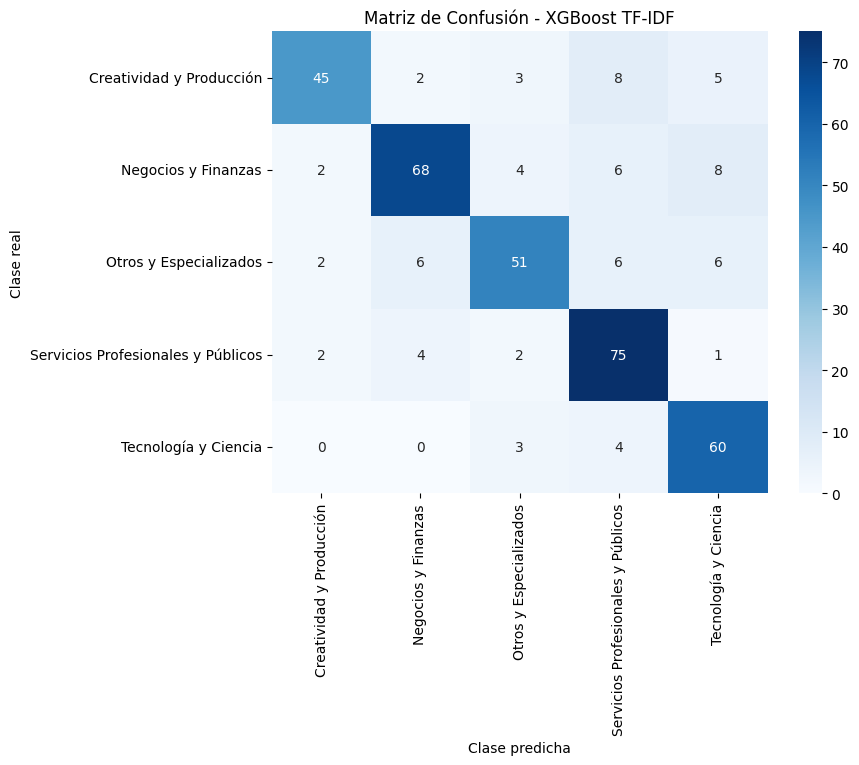


=== COMPARACIÓN REALES VS PREDICHAS (primeras 10 muestras) ===


,Real,Pred
0,Otros y Especializados,Tecnología y Ciencia
1,Servicios Profesionales y Públicos,Servicios Profesionales y Públicos
2,Creatividad y Producción,Creatividad y Producción
3,Creatividad y Producción,Creatividad y Producción
4,Negocios y Finanzas,Negocios y Finanzas
5,Tecnología y Ciencia,Tecnología y Ciencia
6,Otros y Especializados,Otros y Especializados
7,Creatividad y Producción,Creatividad y Producción
8,Otros y Especializados,Otros y Especializados
9,Tecnología y Ciencia,Tecnología y Ciencia


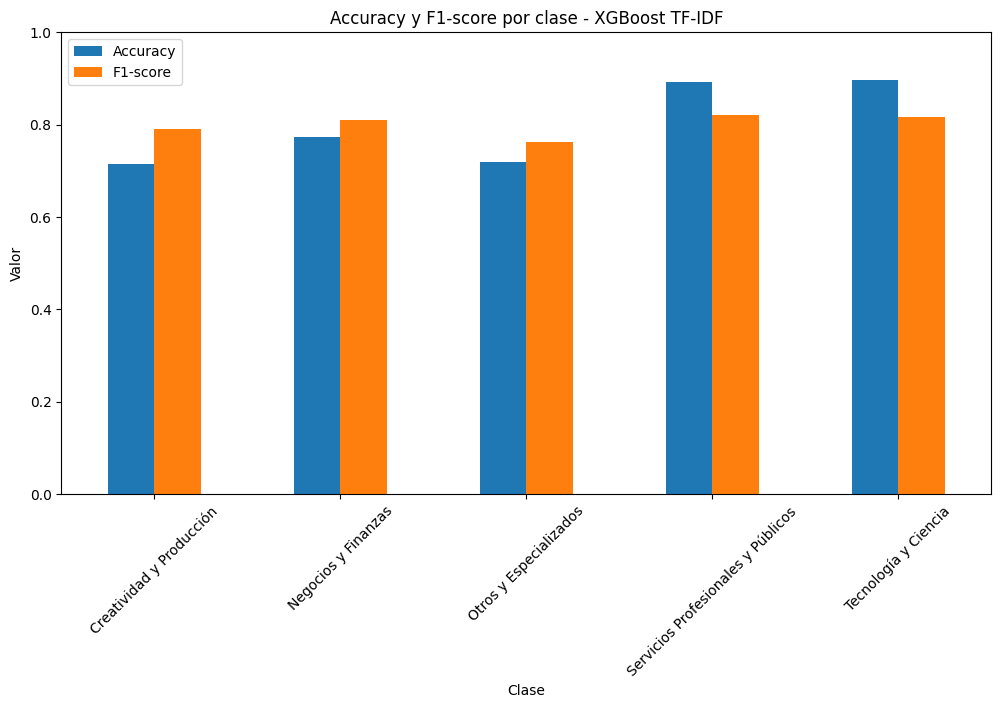


=== EXPERIMENTO REGISTRADO ===
{'Modelo': 'XGBoost_TFIDF', 'max_depth': 5, 'learning_rate': 0.15, 'n_estimators': 200, 'Accuracy': 0.8016085790884718, 'F1_macro': 0.7992380370689737}


In [6]:
# -------------------------
# FUNCIÓN DE EVALUACIÓN
# -------------------------
def evaluate_xgb(model, X, y, le, split_name="test", base_dir="results/XGBoost_TFIDF"):
    """Evalúa el modelo, guarda métricas y reportes por clase, devuelve accuracy, f1, report y matriz de confusión"""
    preds = model.predict(X)
    acc = accuracy_score(y, preds)
    f1 = f1_score(y, preds, average='macro')
    report = classification_report(y, preds, target_names=le.classes_, output_dict=True, zero_division=0)
    cm = confusion_matrix(y, preds)

    # Guardar reportes
    split_dir = os.path.join(base_dir, split_name)
    os.makedirs(split_dir, exist_ok=True)
    pd.DataFrame(report).transpose().to_csv(f"{split_dir}/report.csv")
    pd.DataFrame(cm).to_csv(f"{split_dir}/confusion_matrix.csv", index=False)
    with open(f"{split_dir}/metrics.txt", "w") as f:
        f.write(f"Accuracy: {acc:.4f}\nF1-macro: {f1:.4f}\n\n")
        f.write(pd.DataFrame(report).transpose().to_string())

    return preds, acc, f1, report, cm


# -------------------------
# EVALUACIÓN FINAL
# -------------------------
print("\n=== HIPERPARÁMETROS DEL MODELO ===")
for k, v in params.items():
    print(f"{k}: {v}")

test_preds, test_acc, test_f1, test_report, test_cm = evaluate_xgb(
    xgb, X_test_tfidf, y_test, le, split_name="test", base_dir=base_dir
)

print(f"\n=== MÉTRICAS EN TEST ===\nAccuracy: {test_acc:.4f} | F1-macro: {test_f1:.4f}")

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, test_preds, target_names=le.classes_, zero_division=0))

# -------------------------
# MÉTRICAS POR CLASE
# -------------------------
metrics_df = pd.DataFrame(test_report).transpose()
print("\n=== MÉTRICAS POR CLASE ===")
display(metrics_df.iloc[:-3][['precision', 'recall', 'f1-score']])  # Quita los promedios

# -------------------------
# MATRIZ DE CONFUSIÓN
# -------------------------
plt.figure(figsize=(8,6))
sns.heatmap(test_cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.ylabel("Clase real")
plt.xlabel("Clase predicha")
plt.title("Matriz de Confusión - XGBoost TF-IDF")
plt.show()

# -------------------------
# COMPARACIÓN REALES VS PREDICHAS
# -------------------------
comparison_df = pd.DataFrame({
    "Real": [le.classes_[i] for i in y_test],
    "Pred": [le.classes_[i] for i in test_preds]
})
print("\n=== COMPARACIÓN REALES VS PREDICHAS (primeras 10 muestras) ===")
display(comparison_df.head(10))

# -------------------------
# GRÁFICO DE MÉTRICAS POR CLASE
# -------------------------
per_class_f1 = [test_report[label]['f1-score'] for label in le.classes_]
per_class_acc = [np.mean(test_preds[y_test == i] == i) for i, _ in enumerate(le.classes_)]

metrics_plot_df = pd.DataFrame({
    "Clase": le.classes_,
    "Accuracy": per_class_acc,
    "F1-score": per_class_f1
})
metrics_plot_df.set_index("Clase", inplace=True)
metrics_plot_df.plot(kind='bar', figsize=(12,6))
plt.title("Accuracy y F1-score por clase - XGBoost TF-IDF")
plt.ylabel("Valor")
plt.ylim(0,1)
plt.xticks(rotation=45)
plt.show()

# -------------------------
# REGISTRO EXPERIMENTO
# -------------------------
experiment_tfidf = {
    "Modelo": "XGBoost_TFIDF",
    "max_depth": params["max_depth"],
    "learning_rate": params["learning_rate"],
    "n_estimators": params["n_estimators"],
    "Accuracy": test_acc,
    "F1_macro": test_f1
}

print("\n=== EXPERIMENTO REGISTRADO ===")
print(experiment_tfidf)
